[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/NU-MSE-LECTURES/465-WINTER2026/blob/main/Week_06/assignments/assignment_combined_5_6.ipynb)

# Assignment 5 & 6: HRTEM Simulation and CTF Analysis

In this assignment, you will use the `abTEM` package to perform a multislice High-Resolution Transmission Electron Microscopy (HRTEM) simulation. You will build an atomic model, calculate its projected potential, simulate the electron wave propagation, and apply different Contrast Transfer Functions (CTFs) to understand how microscope parameters affect the final image.

## Learning Objectives
1. Understand the multislice algorithm for HRTEM simulation.
2. Explore the effects of the Contrast Transfer Function (CTF), including spherical aberration ($C_s$) and defocus ($\Delta f$).
3. Analyze the impact of aberration correction and noise on image quality.

---

## Part 1: Setup and Building the Atomic Model

First, we import the necessary libraries and build our atomic model. We will use a Silicon Nitride (Si$_3$N$_4$) crystal structure.

In [ ]:
!pip install abtem
%matplotlib inline

import abtem
import ase
import numpy as np
import matplotlib.pyplot as plt

print(f"abTEM version: {abtem.__version__}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 376.7/376.7 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 40.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 76.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 53.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 519.0/519.0 kB 33.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 79.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 284.1/284.1 kB 23.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 93.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 69.8 MB/s eta 0:00:00
  Attempting uninstall: dask
    Found existing installation: dask 2026.1.2
    Uninstalling dask-2026.1.2:
      Successfully uninstalled dask-2026.1.2
abTEM version: 1.0.9


### Define the Si$_3$N$_4$ Structure
We use the Atomic Simulation Environment (`ase`) to define the unit cell by providing the atomic positions and cell dimensions.

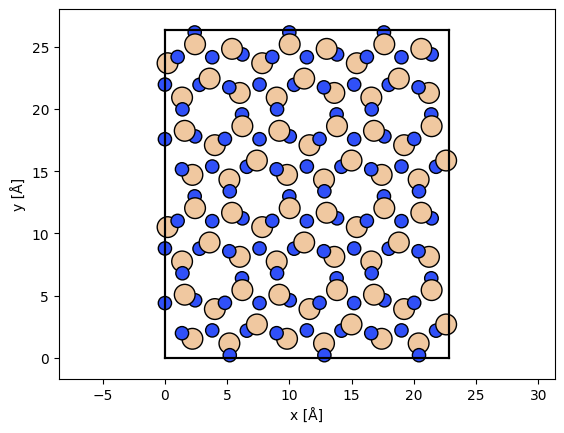

In [ ]:
structure = ase.Atoms(
    'Si6N8',
    positions=[
      (4.015308131006949, 3.9110253242355126, 2.1788993100000003),
      (2.422878997737693, -1.15285715796029, 0.72629977),
      (5.3947013511357, -1.5218461833564767, 0.72629977),
      (2.2098430845971873, 1.521846183356477, 2.1788993100000003),
      (5.181665437995193, 1.1528571579602902, 2.1788993100000003),
      (3.5892363047259375, -3.9110253242355126, 0.72629977),
      (3.8022722178664434, 2.195242888517426, 2.1788993100000003),
      (3.802272217866444, -2.1952428885174267, 0.72629977),
      (6.2321062558996125, -1.9713791971906662, 2.1788993100000003),
      (4.8233175932090955, 4.411472738097657, 0.72629977),
      (5.211060880556961, 0.20287673026395847, 0.72629977),
      (2.3934835551759255, -0.20287673026395803, 2.1788993100000003),
      (1.3724381798332734, 1.9713791971906653, 0.72629977),
      (2.781226842523792, -4.411472738097657, 2.1788993100000003),
    ],
    cell=[7.6045, 7.6045, 2.9052, 90, 90, 120]
)

# The multislice algorithm requires an orthogonal input cell.
structure_orthogonal = abtem.atoms.orthogonalize_cell(structure)

# Visualize the orthogonalized structure (tiled 3x2x6 for visualization)
abtem.show_atoms(structure_orthogonal * (3,2,6), plane='xy');

---

## Part 2: Calculate Projected Potentials

**TASK 1:** Calculate the projected potentials for the structure.
1. Create a `FrozenPhonons` object using the orthogonalized structure tiled by `(3, 2, 17)`. This gives a thickness of ~5 nm. Use 8 configurations and a thermal sigma of 0.1 Å for both Si and N.
2. Create a `Potential` object using the frozen phonons, with a sampling of 0.1 Å, slice thickness of 2.0 Å, and the 'kirkland' parametrization.
3. Plot the mean-projected potential.

tasks:   0%|          | 0/17 [00:00<?, ?it/s]

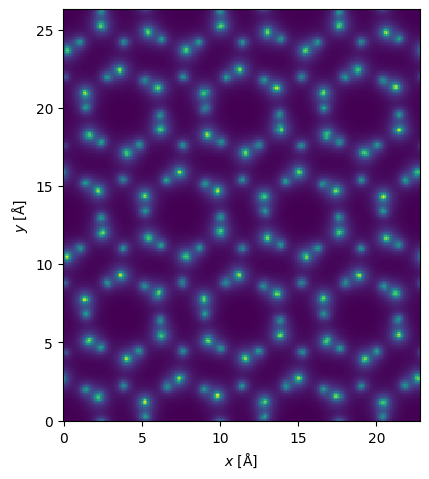

In [ ]:
# TASK 1: Create FrozenPhonons
# Tile the structure by (3, 2, 17) to get ~5 nm thickness
# Use 8 configurations and a thermal sigma of 0.1 Å for both Si and N
frozen_phonons = abtem.FrozenPhonons(
    structure_orthogonal * (3, 2, 17),
    8,
    {'Si': 0.1, 'N': 0.1},
    seed=42,
)

# TASK 1: Create the Potential object
# Use sampling=0.1 Å, slice_thickness=2.0 Å, and the 'kirkland' parametrization
potential = abtem.Potential(
    frozen_phonons,
    sampling=0.1,
    slice_thickness=2.0,
    projection='infinite',
    parametrization='kirkland',
)

# TASK 1: Plot the mean projected potential
# .project() collapses along z; .show() displays it
potential.project().show(cmap='viridis');


---

## Part 3: HRTEM Plane Wave Multislice Simulation

**TASK 2:** Perform the multislice simulation.
1. Initialize a `PlaneWave` with an energy of 300 keV.
2. Run the `multislice` algorithm using the potential you calculated.
3. Plot the mean intensity of the exit waves.

tasks:   0%|          | 0/25 [00:00<?, ?it/s]

tasks:   0%|          | 0/32 [00:00<?, ?it/s]

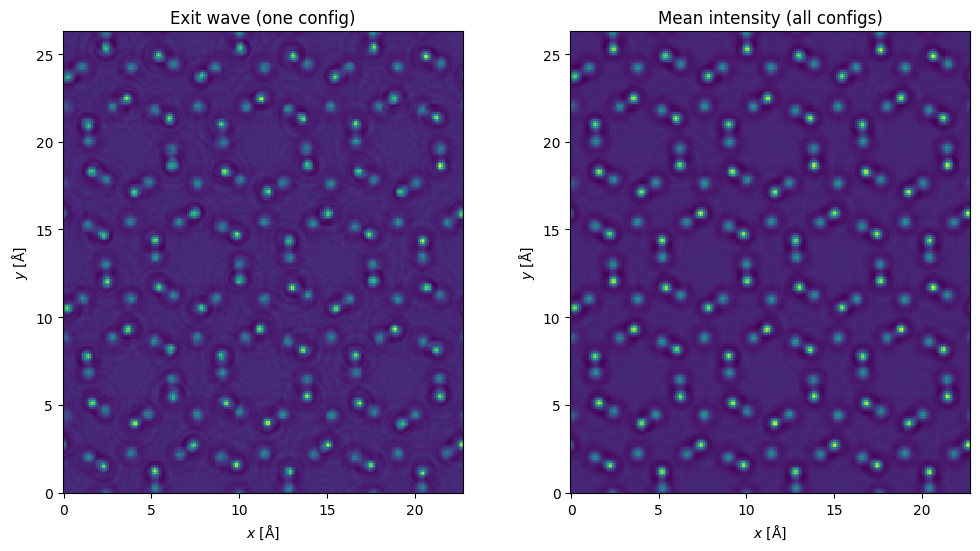

In [ ]:
# TASK 2: Create a 300 keV plane wave
wave = abtem.PlaneWave(energy=300e3)

# TASK 2: Propagate the wave through the potential (multislice)
exit_waves = wave.multislice(potential)

# TASK 2: Display both a single-configuration exit wave and the mean intensity
fig, (ax_single, ax_mean) = plt.subplots(1, 2, figsize=(12, 6))
exit_waves.show(ax=ax_single, cmap='viridis')
ax_single.set_title('Exit wave (one config)')
exit_waves.intensity().mean(0).show(ax=ax_mean, cmap='viridis')
ax_mean.set_title('Mean intensity (all configs)');


---

## Part 4: Contrast Transfer Function (CTF)

The exit wave represents the electron wave immediately after leaving the sample. To simulate the final image, we must apply the Contrast Transfer Function (CTF) of the microscope.

**TASK 3:** Define and apply different CTFs.
1. Define an **uncorrected CTF** with $C_{10} = -600$ Å (defocus) and $C_{30} = 1.3 \times 10^7$ Å ($C_s = 1.3$ mm).
2. Define an **aberration-corrected CTF** with $C_{10} = 30$ Å and $C_{30} = -8 \times 10^4$ Å.
3. Plot both CTFs to compare them.
4. Apply both CTFs to your `exit_waves` and plot the resulting mean image intensities.

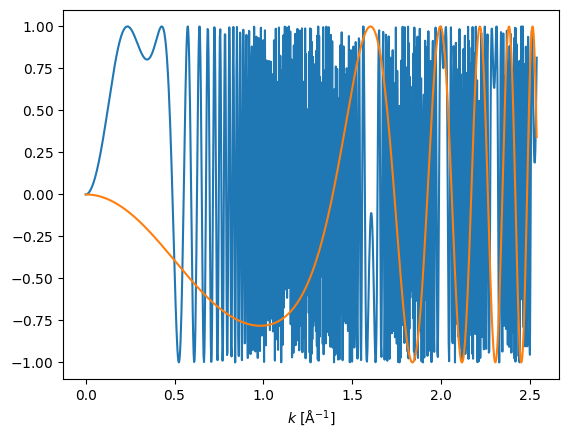

In [ ]:
# TASK 3a: Uncorrected CTF (conventional TEM with Cs = 1.3 mm)
# defocus = -C10, Cs = C30
ctf_uncorrected = abtem.CTF(
    energy=300e3,
    defocus=600,           # defocus (positive = underfocus) in Å
    Cs=1.3e7,              # spherical aberration in Å (1.3 mm)
)

# TASK 3b: Aberration-corrected CTF (small residual aberrations)
ctf_corrected = abtem.CTF(
    energy=300e3,
    defocus=-30,           # slight overfocus in Å
    Cs=-8e4,               # small negative residual Cs
)

# TASK 3c: Overlay both CTFs on a single plot for comparison
fig, ax = plt.subplots()
ctf_uncorrected.profiles(max_angle=50).show(ax=ax, units='mrad')
ctf_corrected.profiles(max_angle=50).show(ax=ax, units='mrad');

tasks:   0%|          | 0/32 [00:00<?, ?it/s]

tasks:   0%|          | 0/32 [00:00<?, ?it/s]

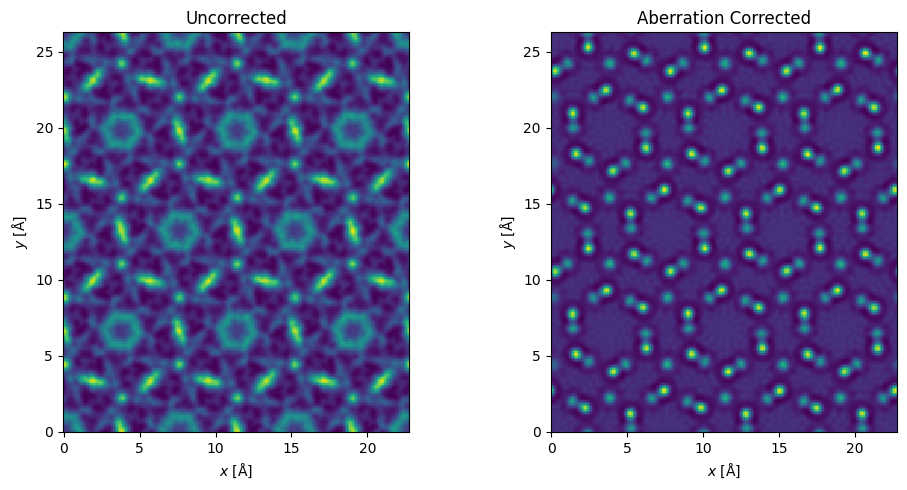

In [ ]:
# TASK 3d: Convolve exit waves with each CTF in Fourier space
image_uncorrected = exit_waves.apply_ctf(ctf_uncorrected)
image_corrected = exit_waves.apply_ctf(ctf_corrected)

# TASK 3d: Compare resulting images
fig, (ax_uc, ax_co) = plt.subplots(1, 2, figsize=(10, 5))

image_uncorrected.intensity().mean(0).show(
    cmap='viridis',
    ax=ax_uc
)
ax_uc.set_title('Uncorrected')

image_corrected.intensity().mean(0).show(
    cmap='viridis',
    ax=ax_co
)
ax_co.set_title('Aberration Corrected')

fig.tight_layout();


---

## Part 5: Noise and Dose

Real TEM images are affected by Poisson noise due to the finite electron dose.

**TASK 4:** Apply Poisson noise to your images.
1. Use `abtem.noise.poisson_noise` to apply a dose of $100$ $e^-$/Å$^2$ to your aberration-corrected image.
2. Plot the noisy image alongside the noiseless one for comparison.

tasks:   0%|          | 0/32 [00:00<?, ?it/s]

tasks:   0%|          | 0/33 [00:00<?, ?it/s]

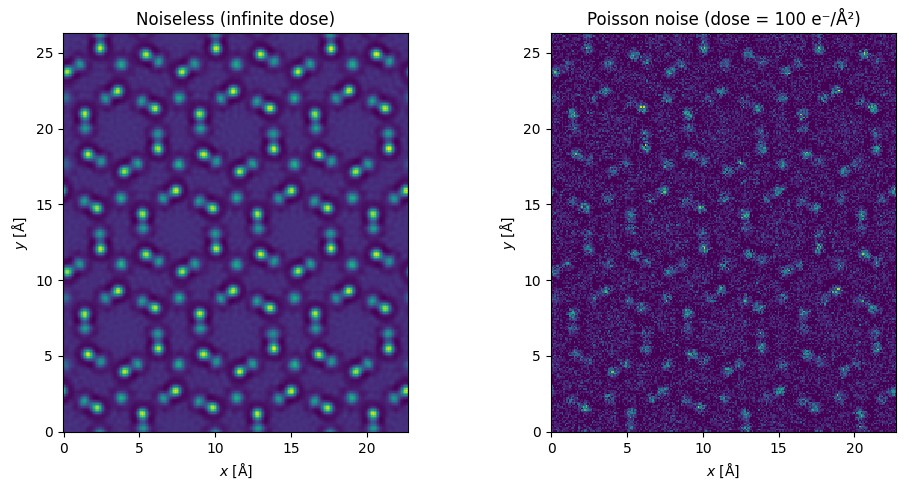

In [ ]:
# TASK 4: Add Poisson noise to the corrected image at 100 e⁻/Å²
dose = 100  # electrons per Å²
corrected_intensity = image_corrected.intensity().mean(0)
noisy_img = corrected_intensity.poisson_noise(dose_per_area=dose)

# TASK 4: Side-by-side comparison of noiseless vs. noisy
fig, (ax_clean, ax_noisy) = plt.subplots(1, 2, figsize=(10, 5))

corrected_intensity.show(ax=ax_clean, cmap='viridis')
ax_clean.set_title('Noiseless (infinite dose)')

noisy_img.show(ax=ax_noisy, cmap='viridis')
ax_noisy.set_title(f'Poisson noise (dose = {dose} e⁻/Å²)')

fig.tight_layout();

---

# Task 6: Self-Reflection

Based on your simulations above, answer the following questions:

**1. Contrast Transfer Function (CTF):**
- How does the uncorrected CTF differ from the aberration-corrected CTF in terms of spatial frequency transfer?
- Why do we see sharper atomic columns in the aberration-corrected image?

**2. Defocus and Contrast:**
- Why don't we typically image at exactly zero defocus ($\Delta f = 0$) in a conventional (uncorrected) TEM?
- What is the significance of the Scherzer defocus?

**3. Simulation vs. Reality:**
- How does adding Poisson noise change the interpretability of the image?
- What other experimental factors (not simulated here) might degrade the quality of a real HRTEM image?

**4. Multislice Algorithm:**
- Why is the multislice method necessary for a 5 nm thick sample, rather than just using a single projected potential (kinematic approximation)?

### Your Answers:

**1. Contrast Transfer Function (CTF):**
- The uncorrected CTF exhibits rapid oscillations at higher spatial frequencies, resulting in inconsistent phase transfer—some frequencies are passed with positive contrast, others with negative contrast, and certain frequencies are completely suppressed. In contrast, the aberration-corrected CTF maintains a broad, nearly flat passband before oscillations begin, enabling uniform transfer across a much wider frequency range. Sharper atomic columns appear in the corrected image because high spatial frequencies are transferred with the same phase sign as the lower frequencies. This coherent recombination produces well-localized intensity peaks at column positions, often referred to as "white-atom" contrast.

**2. Defocus and Contrast:**
- At exact zero defocus (Δf = 0), the CTF essentially vanishes at low spatial frequencies for a thin phase object, producing negligible amplitude contrast. A controlled amount of underfocus is needed to convert phase shifts from the specimen into measurable intensity variations in the image. Scherzer defocus is the optimal underfocus condition that counterbalances the phase shift introduced by spherical aberration. It maximizes the width of the passband where the CTF stays close to –1, thereby extending the interpretable resolution limit of the microscope.

**3. Simulation vs. Reality:**
- Poisson noise introduces shot-noise fluctuations that reflect the statistical nature of finite electron dose. These fluctuations can mask fine structural features, particularly for light-element columns or beam-sensitive specimens imaged under low-dose conditions. Additional experimental degradation sources not captured here include specimen drift during acquisition, mechanical vibrations, chromatic aberration (energy spread/lens current instability), the detector modulation transfer function (MTF/DQE), amorphous contamination or oxide layers on the sample surface, and inelastic (plural) scattering in thicker regions.

**4. Multislice Algorithm:**
- At 5 nm thickness, multiple scattering (dynamical diffraction) is already significant. The kinematic approximation treats the specimen as a single projected potential and assumes each electron scatters at most once, which breaks down as thickness increases. The multislice method divides the specimen into thin slices and alternates transmission and free-space propagation, correctly accounting for the cumulative phase and amplitude changes the electron wave experiences as it traverses multiple atomic layers.
